## Time Series Forecasting Fundamentals with TensorFlow

#### Let's predict the price of Bitcoin based on the historical price of Bitcoin.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import datetime as dt
import os
import tensorflow as tf
warnings.filterwarnings("ignore")
print(tf.__version__)

2.18.0


## Get the data...

In [2]:
# !mkdir ~/.kaggle
# !cp /content/drive/MyDrive/Kaggle_API/kaggle.json ~/.kaggle/
# !chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download mczielinski/bitcoin-historical-data
!unzip bitcoin-historical-data

Dataset URL: https://www.kaggle.com/datasets/mczielinski/bitcoin-historical-data
License(s): CC-BY-SA-4.0
bitcoin-historical-data.zip: Skipping, found more recently modified local copy (use --force to force download)
Archive:  bitcoin-historical-data.zip
replace btcusd_1-min_data.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n


In [3]:
df = pd.read_csv("/content/btcusd_1-min_data.csv")
df.head()

,Timestamp,Open,High,Low,Close,Volume
0,1.325412e+09,4.58,4.58,4.58,4.58,0.0
1,1.325412e+09,4.58,4.58,4.58,4.58,0.0
2,1.325412e+09,4.58,4.58,4.58,4.58,0.0
3,1.325412e+09,4.58,4.58,4.58,4.58,0.0
4,1.325412e+09,4.58,4.58,4.58,4.58,0.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6780281 entries, 0 to 6780280
Data columns (total 6 columns):
 #   Column     Dtype  
---  ------     -----  
 0   Timestamp  float64
 1   Open       float64
 2   High       float64
 3   Low        float64
 4   Close      float64
 5   Volume     float64
dtypes: float64(6)
memory usage: 310.4 MB


In [5]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
df['Date'] = df['Timestamp'].dt.date
df['Time'] = df['Timestamp'].dt.time
df.head()

,Timestamp,Open,High,Low,Close,Volume,Date,Time
0,2012-01-01 10:01:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,2012-01-01 10:02:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,2012-01-01 10:03:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,2012-01-01 10:04:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,2012-01-01 10:05:00,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [6]:
df = df.drop(['Timestamp'], axis=1)
df.head()

,Open,High,Low,Close,Volume,Date,Time
0,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:01:00
1,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:02:00
2,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:03:00
3,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:04:00
4,4.58,4.58,4.58,4.58,0.0,2012-01-01,10:05:00


In [7]:
df = df.groupby('Date')['Close'].mean().reset_index()
df.head()

,Date,Close
0,2012-01-01,4.645697
1,2012-01-02,4.975000
2,2012-01-03,5.085500
3,2012-01-04,5.170396
4,2012-01-05,5.954361


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4819 entries, 0 to 4818
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    4819 non-null   object 
 1   Close   4819 non-null   float64
dtypes: float64(1), object(1)
memory usage: 75.4+ KB


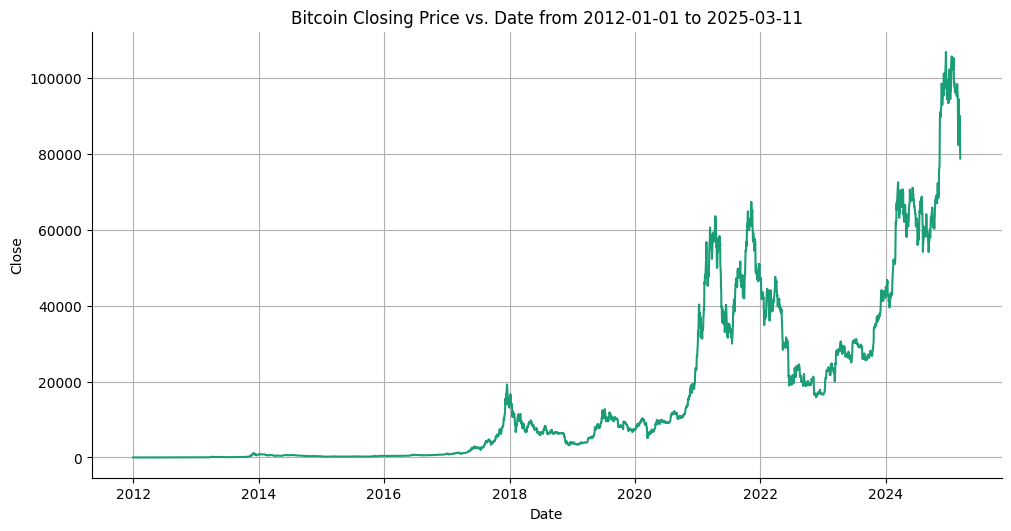

In [9]:
# @title Date vs Close

def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Date']
  ys = series['Close']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])
  plt.title(f"Bitcoin Closing Price vs. Date from {xs.min()} to {xs.max()}")
  plt.grid(True)
  return plt

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = df.sort_values('Date', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Date')
_ = plt.ylabel('Close')

#### Convert dataset columns to Numpy arrays.

In [10]:
timesteps = df['Date'].to_numpy()
prices = df['Close'].to_numpy()
timesteps,prices

(array([datetime.date(2012, 1, 1), datetime.date(2012, 1, 2),
        datetime.date(2012, 1, 3), ..., datetime.date(2025, 3, 9),
        datetime.date(2025, 3, 10), datetime.date(2025, 3, 11)],
       dtype=object),
 array([4.64569726e+00, 4.97500000e+00, 5.08550000e+00, ...,
        8.61820000e+04, 8.05097307e+04, 7.87630000e+04]))

#### Create train and test splits

In [11]:
split_size = int(np.size(timesteps) * 0.8)
X_train, X_test = timesteps[:split_size], timesteps[split_size:]
y_train, y_test = prices[:split_size], prices[split_size:]
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3855,), (964,), (3855,), (964,))

#### Plot train and test datasets.

In [12]:
# Create a function to plot time series data
def plot_time_series(timesteps, values, format='.', start=0, end=None, label=None):
  """
  Plots a timesteps (a series of points in time) against values (a series of values across timesteps).

  Parameters
  ---------
  timesteps : array of timesteps
  values : array of values across time
  format : style of plot, default "."
  start : where to start the plot (setting a value will index from start of timesteps & values)
  end : where to end the plot (setting a value will index from end of timesteps & values)
  label : label to show on plot of values
  """
  # Plot the series
  plt.plot(timesteps[start:end], values[start:end], format, label=label)
  plt.xlabel("Time")
  plt.ylabel("BTC Price")
  if label:
    plt.legend(fontsize=14) # make label bigger
  plt.grid(True)


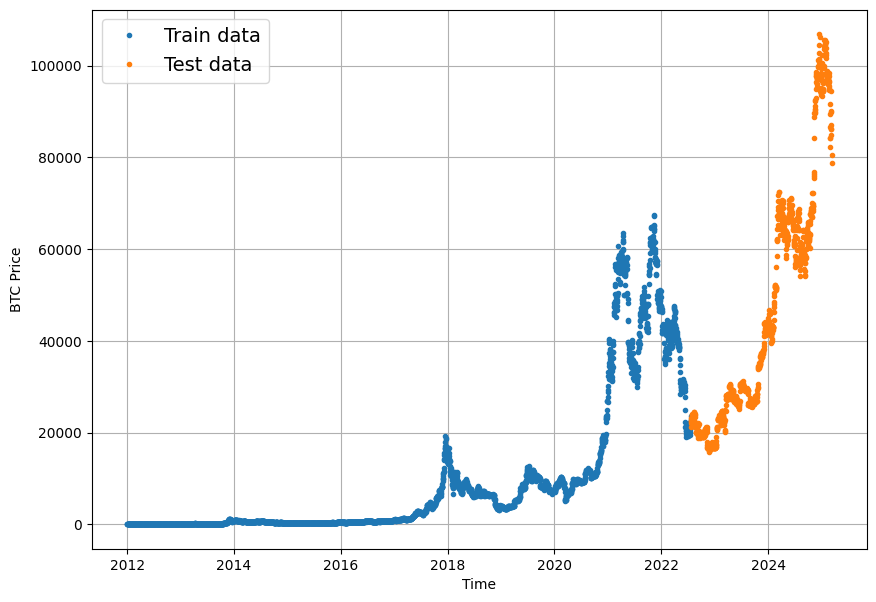

In [13]:
# Try out our plotting function
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")

## Let's Build A Few Models.

Model Number | Model Type  | Horizon size | Window size | Extra data |
-------------|-------------|--------------|-------------|------------|
0 | Naive model (baseline) |    NA        |     NA      |  NA        |      
1 | Dense model            | 1 | 7 | NA |
2	|Same as 1	|1	|30	|NA|
3	|Same as 1|	7	|30	|NA|
4	|Conv1D	|1	|7	|NA|
5	|LSTM	|1	|7	|NA|
6	|Same as 1 (but with multivariate data)|	1|	7|	Block reward size
7	|N-BEATs Algorithm|	1	|7	|NA |
8	|Ensemble (multiple models optimized on different loss functions)|	1	|7	|NA
9	|Future prediction model (model to predict future values)|	1|	7	|NA|
10|	Same as 1 (but with turkey 🦃 data introduced)|	1	|7	|NA|


#### Model 0: Naive Forecast where   $\hat{y_t} = y_{t-1}$

In [14]:
# Create a naïve forecast
naive_forecast = y_test[:-1] # Naïve forecast equals every value excluding the last value
naive_forecast[:10], naive_forecast[-10:] # View first 10 and last 10

(array([23219.21743056, 22571.84520139, 22590.34086806, 22096.39465278,
        21178.70126389, 21368.88505556, 23129.02411111, 23893.62595833,
        24059.26191667, 23771.4133125 ]),
 array([84288.        , 89412.8008008 , 94422.        , 84901.57157157,
        87172.        , 90110.16716717, 89873.        , 86165.7967968 ,
        86182.        , 80509.73073073]))

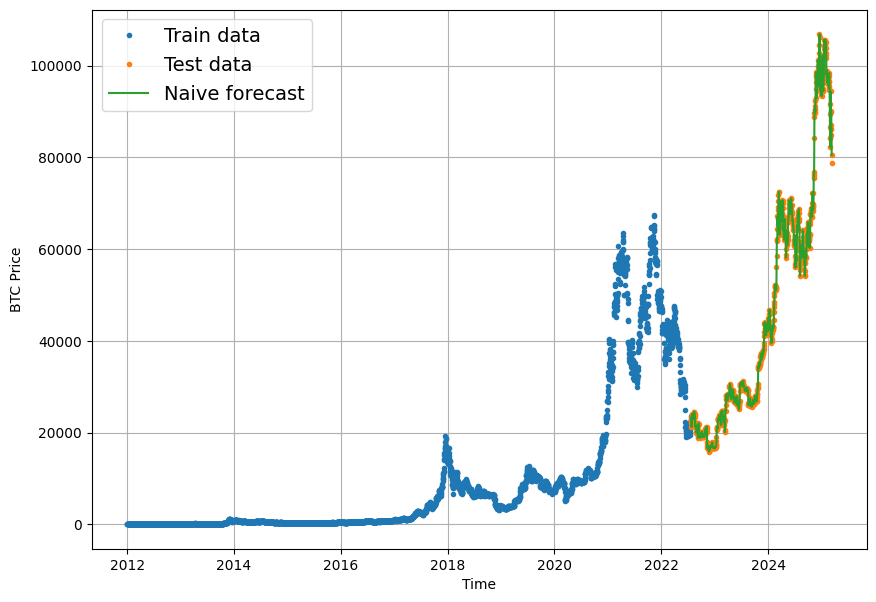

In [15]:
# Plot naive forecast
plt.figure(figsize=(10, 7))
plot_time_series(timesteps=X_train, values=y_train, label="Train data")
plot_time_series(timesteps=X_test, values=y_test, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", label="Naive forecast");

#### Let's zoom in on the above plot...

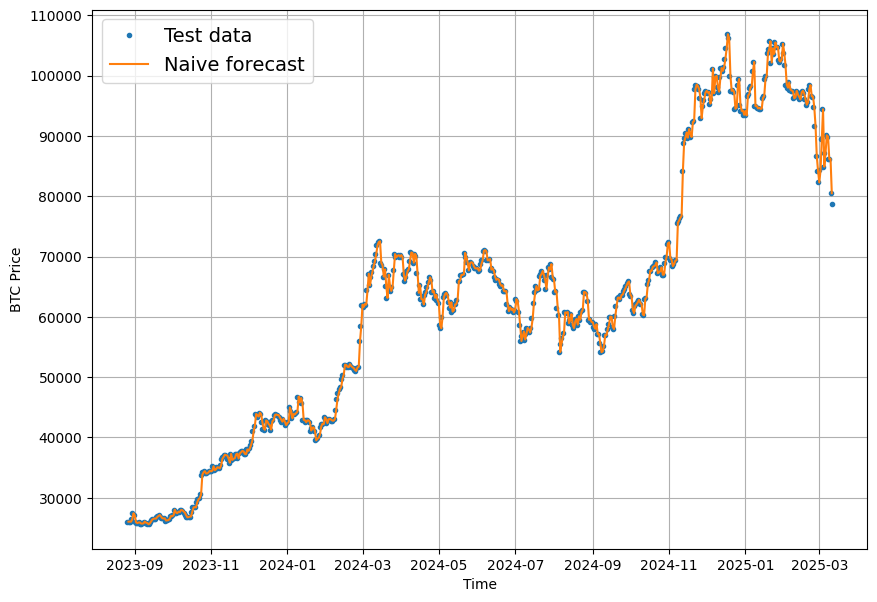

In [16]:
plt.figure(figsize=(10, 7))
offset = 400 # offset the values by 400 timesteps
plot_time_series(timesteps=X_test, values=y_test, start=offset, label="Test data")
plot_time_series(timesteps=X_test[1:], values=naive_forecast, format="-", start=offset, label="Naive forecast");


#### Scale-dependent errors

These are metrics which can be used to compare time series values and forecasts that are on the same scale.

For example, Bitcoin historical prices in USD versus Bitcoin forecast values in USD.

We can use

* `tf.keras.metrics.mean_absolute_error()`
* `tf.sqrt(tf.keras.metrics.mean_squared_error())`

In [17]:
# MASE implemented courtesy of sktime - https://github.com/alan-turing-institute/sktime/blob/ee7a06843a44f4aaec7582d847e36073a9ab0566/sktime/performance_metrics/forecasting/_functions.py#L16
def mean_absolute_scaled_error(y_true, y_pred):
  """
  Implement MASE (assuming no seasonality of data).
  """
  mae = tf.reduce_mean(tf.abs(y_true - y_pred))

  # Find MAE of naive forecast (no seasonality)
  mae_naive_no_season = tf.reduce_mean(tf.abs(y_true[1:] - y_true[:-1])) # our seasonality is 1 day (hence the shifting of 1 day)

  return mae / mae_naive_no_season

#### Set up instances of `mae`, `mse` and `mape`.

In [18]:
mae = tf.keras.losses.MeanAbsoluteError()
mse = tf.keras.losses.MeanSquaredError()
mape = tf.keras.losses.MeanAbsolutePercentageError()

In [19]:
def evaluate_preds(y_true, y_pred):
  # Make sure float32 (for metric calculations)
  y_true = tf.cast(y_true, dtype=tf.float32)
  y_pred = tf.cast(y_pred, dtype=tf.float32)

  # Calculate various metrics
  mae_result = mae(y_true, y_pred)
  mse_result = mse(y_true, y_pred) # puts and emphasis on outliers (all errors get squared)
  rmse = tf.sqrt(mse_result)
  mape_result = mape(y_true, y_pred)

  return {"mae": mae_result.numpy(),
          "mse": mse_result.numpy(),
          "rmse": rmse.numpy(),
          "mape": mape_result.numpy()}

In [20]:
naive_results = evaluate_preds(y_true=y_test[1:],
                               y_pred=naive_forecast)
naive_results

{'mae': 721.3539, 'mse': 1531601.8, 'rmse': 1237.579, 'mape': 1.4889243}

In [21]:
# Find average price of Bitcoin in test dataset
tf.reduce_mean(y_test).numpy()

46208.518889035404

Okay, looking at these two values is starting to give us an idea of how our model is performing:

The average price of Bitcoin in the test dataset is: $46,091 (note: average may not be the best measure here, since the highest price is over 3x this value and the lowest price is over 4x lower)

Each prediction in naive forecast is on average off by: $714.

Can we do better than this??

#### Windowing

Windowing is a method to turn a time series dataset into supervised learning problem.

In other words, we want to use windows of the past to predict the future.

For example for a univariate time series, windowing for one week (window=7) to predict the next single value (horizon=1) might look like:

```
Window for one week (univariate time series)

[0, 1, 2, 3, 4, 5, 6] -> [7]

[1, 2, 3, 4, 5, 6, 7] -> [8]

[2, 3, 4, 5, 6, 7, 8] -> [9]

```

In [22]:
HORIZON = 1 # predict 1 step at a time
WINDOW_SIZE = 7 # use a week worth of timesteps to predict the horizon

In [23]:
# Create function to label windowed data
def get_labeled_windows(x, horizon=1):
  """
  Creates labels for windowed dataset.

  E.g. if horizon=1 (default)
  Input: [1, 2, 3, 4, 5, 6] -> Output: ([1, 2, 3, 4, 5], [6])
  """
  return x[:, :-horizon], x[:, -horizon:]

In [24]:
x = tf.expand_dims(np.array([1, 2, 3, 4, 5, 6]),axis=0)
x[:,:-1]

<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>

In [25]:
x[:,-1:]

<tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>

In [26]:
get_labeled_windows(x, horizon=1)

(<tf.Tensor: shape=(1, 5), dtype=int64, numpy=array([[1, 2, 3, 4, 5]])>,
 <tf.Tensor: shape=(1, 1), dtype=int64, numpy=array([[6]])>)

In [27]:
# Create function to view NumPy arrays as windows
def make_windows(x, window_size, horizon):
  """
  Turns a 1D array into a 2D array of sequential windows of window_size.
  """
  # 1. Create a window of specific window_size (add the horizon on the end for later labelling)
  window_step = np.expand_dims(np.arange(window_size+horizon), axis=0)
  # print(f"Window step:\n {window_step}")

  # 2. Create a 2D array of multiple window steps (minus 1 to account for 0 indexing)
  window_indexes = window_step + np.expand_dims(np.arange(len(x)-(window_size+horizon-1)), axis=0).T # create 2D array of windows of size window_size
  # print(f"Window indexes:\n {window_indexes[:3], window_indexes[-3:], window_indexes.shape}")

  # 3. Index on the target array (time series) with 2D array of multiple window steps
  windowed_array = x[window_indexes]

  # 4. Get the labelled windows
  windows, labels = get_labeled_windows(windowed_array, horizon=horizon)

  return windows, labels

#### The above function is broken out below for better understanding.

In [28]:
# window_step = np.expand_dims(np.arange(WINDOW_SIZE+HORIZON), axis=0)
# window_step

In [29]:
# window_indexes = window_step + np.expand_dims(np.arange(len(prices)-(WINDOW_SIZE+HORIZON-1)), axis=0).T
# window_indexes

In [30]:
# windowed_array = prices[window_indexes]
# windowed_array

In [31]:
# windows, labels = get_labelled_windows(windowed_array, horizon=HORIZON)
# windows, labels

#### Turning windowed data in train and test datasets...

In [32]:
full_windows, full_labels = make_windows(prices, window_size=WINDOW_SIZE, horizon=HORIZON)
full_windows.shape, full_labels.shape

((4812, 7), (4812, 1))

In [33]:
from posixpath import split
def make_train_test_splits(windows, labels, test_split=0.2):
  """
  Splits matching pairs of windows and labels into train and test splits.

  """
  split_size = int(len(windows) * (1-test_split))
  train_windows = windows[:split_size]
  test_windows = windows[split_size:]
  train_labels = labels[:split_size]
  test_labels = labels[split_size:]

  return train_windows, test_windows, train_labels, test_labels

In [34]:
train_split = 0.8
split_size = int(len(full_windows) * train_split)
split_size

3849

In [35]:
train_windows,test_windows,train_labels,test_labels = make_train_test_splits(full_windows, full_labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((3849, 7), (963, 7), (3849, 1), (963, 1))

Let's check to insure the train labels are the same before and after the window split.

In [36]:
train_labels[:-HORIZON], train_labels[:-HORIZON].shape, y_train[WINDOW_SIZE:], y_train[WINDOW_SIZE:].shape

(array([[6.81944444e+00],
        [6.81645139e+00],
        [6.38572222e+00],
        ...,
        [2.22559803e+04],
        [2.35830194e+04],
        [2.29761827e+04]]),
 (3848, 1),
 array([6.81944444e+00, 6.81645139e+00, 6.38572222e+00, ...,
        2.22559803e+04, 2.35830194e+04, 2.29761827e+04]),
 (3848,))

Okay...looks good!

In [37]:
np.array_equal(np.squeeze(train_labels[:-HORIZON]),y_train[WINDOW_SIZE:])

True

#### We need to make a modeling checkpoint to capture the best performance of each model at the epoch where the best performance is observed.

In [38]:

import os

# Create a function to implement a ModelCheckpoint callback with a specific filename
def create_model_checkpoint(model_name, save_path="model_experiments"):
  return tf.keras.callbacks.ModelCheckpoint(filepath=os.path.join(save_path, model_name), # create filepath to save model
                                            verbose=0, # only output a limited amount of text
                                            save_best_only=True) # save only the best model to file

## `Model_1`:

* A single dense layer with 128 hidden units and ReLU (rectified linear unit) activation
* An output layer with linear activation (or no activation)
* Adam optimizer and MAE loss function
* Batch size of 128
* 100 epochs


In [39]:
import tensorflow as tf
from tensorflow.keras import layers

# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_1 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
  ], name="model_1_dense.keras") # give the model a name so we can save it

# Compile model
model_1.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_1.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_1.name)]) # create ModelCheckpoint callback to save best model



Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 4321.0352 - mae: 4321.0352 - val_loss: 2079.8367 - val_mae: 2079.8367
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 513.7636 - mae: 513.7636 - val_loss: 1308.7494 - val_mae: 1308.7494
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 408.6094 - mae: 408.6094 - val_loss: 1228.6149 - val_mae: 1228.6149
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 386.2472 - mae: 386.2472 - val_loss: 1120.7996 - val_mae: 1120.7996
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 354.4065 - mae: 354.4065 - val_loss: 1040.7045 - val_mae: 1040.7045
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 335.7852 - mae: 335.7852 - val_loss: 1082.6858 - val_mae: 1082.6858
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 329.4896 - mae: 329.4896 - val_loss: 1179.2341 - val_mae: 1179.2341
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 316.2744 - mae: 316.2744 - val_loss: 1155.0800 - 

In [40]:
# Evaluate model on test data
model_1.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 448.2593 - mae: 448.2593 


[727.7902221679688, 727.7902221679688]

In [41]:
# Load in saved best performing model_1 and evaluate on test data
model_1 = tf.keras.models.load_model("model_experiments/model_1_dense.keras")
model_1.evaluate(test_windows, test_labels)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 447.7300 - mae: 447.7300


[721.3233642578125, 721.3233642578125]

## Making forecasts with a model (on the test dataset)

Since we're going to be running more modeling experiments, let's write a function which:

* Takes in a trained model (just like `model_1`)
* Takes in some input data (just like the data the model was trained on)
* Passes the input data to the model's `predict()` method
* Returns the predictions

In [42]:
def make_preds(model, input_data):
  """
  Uses model to make predictions on input_data.

  Parameters
  ----------
  model: trained model
  input_data: windowed input data (same kind of data model was trained on)

  Returns model predictions on input_data.
  """
  # forecast = model.predict(input_data)
  # return tf.squeeze(forecast) # return 1D array of predictions
  return model.predict(input_data)

In [43]:
model_1_preds = make_preds(model_1, test_windows)

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


Compare `y_preds` to `test_labels`

In [44]:
model_1_results = evaluate_preds(y_true=test_labels,
               y_pred=make_preds(model_1, test_windows))

31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


How does this performance compare with the naive forecast?

In [45]:
naive_results

{'mae': 721.3539, 'mse': 1531601.8, 'rmse': 1237.579, 'mape': 1.4889243}

Okay, we see that `model_1` performs about as good as the naive model. We should be able to do better! 💪

Let's use the `plot_time_series()` function to plot `model_1_preds` against the test data.

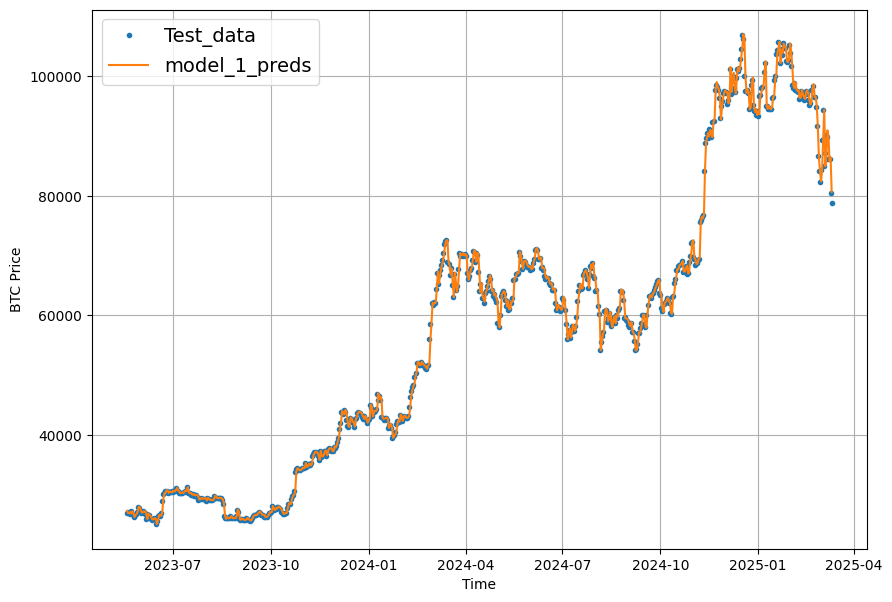

In [46]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_1_preds, start=offset, format="-", label="model_1_preds")


## `Model_2`:

* Use `model_1` with a window_size = 30 and horizon = 1

In [47]:
windows, labels = make_windows(prices, window_size=30, horizon=1)
train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows, labels)
train_windows.shape, test_windows.shape, train_labels.shape, test_labels.shape

((3831, 30), (958, 30), (3831, 1), (958, 1))

In [48]:
prices[:100], train_windows,train_labels

(array([4.64569726, 4.975     , 5.0855    , 5.17039583, 5.95436111,
        6.62033333, 6.04777778, 6.81944444, 6.81645139, 6.38572222,
        7.03033333, 6.97925   , 6.70711806, 6.49223611, 6.61107639,
        7.07152778, 7.00597222, 6.45834722, 6.53438889, 6.47508333,
        6.95      , 6.58236111, 6.60285417, 6.50035417, 6.59415278,
        6.27007639, 5.85440972, 5.27644444, 5.55984028, 5.45683333,
        5.66229167, 5.44102778, 6.03856944, 6.17535417, 6.30867361,
        5.92882639, 5.56186111, 5.66415278, 5.69008333, 5.78751389,
        5.88292361, 5.72289583, 5.53925   , 5.62697917, 5.31605556,
        4.88129861, 4.59868056, 4.68467361, 4.44534722, 4.31546528,
        4.46538194, 4.45179167, 4.50611806, 4.67306944, 5.10198611,
        5.00676389, 4.99197917, 4.99602778, 5.02986111, 4.96924306,
        5.011     , 4.83697222, 4.79349306, 4.68388194, 4.89986806,
        5.006875  , 5.01949306, 4.94740972, 5.01295139, 4.93270139,
        4.93958333, 4.98784722, 5.04125694, 5.34

In [49]:
# Set random seed for as reproducible results as possible
tf.random.set_seed(42)

# Construct model
model_2 = tf.keras.Sequential([
  layers.Dense(128, activation="relu"),
  layers.Dense(HORIZON, activation="linear") # linear activation is the same as having no activation
  ], name="model_2_dense.keras") # give the model a name so we can save it

# Compile model
model_2.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

# Fit model
model_2.fit(x=train_windows, # train windows of 7 timesteps of Bitcoin prices
            y=train_labels, # horizon value of 1 (using the previous 7 timesteps to predict next day)
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model_2.name)]) # create ModelCheckpoint callback to save best model

Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 2498.7722 - mae: 2498.7722 - val_loss: 3706.0120 - val_mae: 3706.0120
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 754.4178 - mae: 754.4178 - val_loss: 2199.7307 - val_mae: 2199.7307
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 580.6043 - mae: 580.6043 - val_loss: 1453.3326 - val_mae: 1453.3326
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 459.1190 - mae: 459.1190 - val_loss: 2381.8533 - val_mae: 2381.8533
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 675.5399 - mae: 675.5399 - val_loss: 2154.6626 - val_mae: 2154.6626
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 558.2357 - mae: 558.2357 - val_loss: 1515.2344 - val_mae: 1515.2344
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 413.6894 - mae: 413.6894 - val_loss: 1293.8669 - val_mae: 1293.8669
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 390.8876 - mae: 390.8876 - val_loss: 1495.5802 - 

In [50]:
# Evaluate model on test data
model_2.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1002.0261 - mae: 1002.0261


[1565.115234375, 1565.115234375]

In [51]:
# Load in saved best performing model_2 and evaluate on test data
model_2 = tf.keras.models.load_model("model_experiments/model_2_dense.keras")
model_2.evaluate(test_windows, test_labels)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 527.6360 - mae: 527.6360


[863.676025390625, 863.676025390625]

In [52]:
model_2_preds = make_preds(model_2, test_windows)

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [53]:
model_2_results = evaluate_preds(y_true=test_labels,
               y_pred=make_preds(model_2, test_windows))
model_2_results

30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


{'mae': 863.6761, 'mse': 1946302.1, 'rmse': 1395.0994, 'mape': 1.7928404}

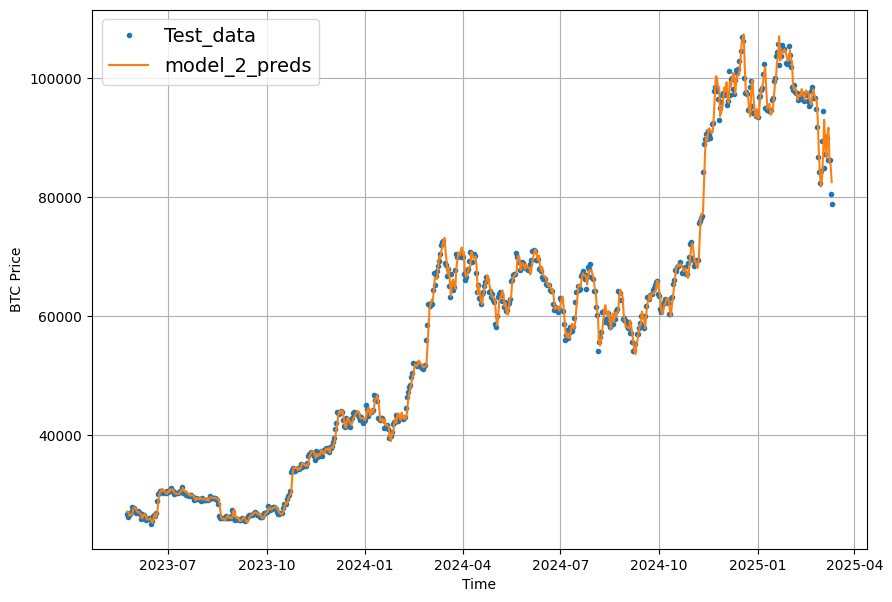

In [54]:
offset = 300
plt.figure(figsize=(10, 7))
# Account for the test_window offset and index into test_labels to ensure correct plotting
plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
plot_time_series(timesteps=X_test[-len(test_windows):], values=model_2_preds, start=offset, format="-", label="model_2_preds")

## `Model_3`

* WINDOW_SIZE=30
* HORIZON=7

In [55]:
HORIZON = 7
WINDOW_SIZE = 30

In [56]:
def prepare_model_data(prices, window_size, horizon):

  # Prepare windows and labels and then split into train and test
  windows, labels = make_windows(prices, window_size=window_size, horizon=horizon)
  train_windows, test_windows, train_labels, test_labels = make_train_test_splits(windows, labels)
  return train_windows, test_windows, train_labels, test_labels

In [57]:
def train_model(model_num, train_windows, test_windows, train_labels, test_labels, horizon):

  # Set random seed for as reproducible results as possible
  tf.random.set_seed(42)

  # Construct model
  model = tf.keras.Sequential([
      layers.Dense(128, activation="relu"),
      layers.Dense(horizon, activation="linear") # linear activation is the same as having no activation
      ], name=f"model_{model_num}_dense.keras") # give the model a name so we can save it

  # Compile model
  model.compile(loss="mae",
                optimizer=tf.keras.optimizers.Adam(),
                metrics=["mae"]) # we don't necessarily need this when the loss function is already MAE

  # Fit model
  model.fit(x=train_windows, # train_windows prices
            y=train_labels, # len(y) = horizon
            epochs=100,
            verbose=1,
            batch_size=128,
            validation_data=(test_windows, test_labels),
            callbacks=[create_model_checkpoint(model_name=model.name)]) # create ModelCheckpoint callback to save best model

  model_evaluate = model.evaluate(test_windows, test_labels)

  # Load in saved best performing model_2 and evaluate on test data
  model = tf.keras.models.load_model(f"model_experiments/model_{model_num}_dense.keras")
  model.evaluate(test_windows, test_labels)
  model_preds = make_preds(model, test_windows)
  model_results = evaluate_preds(y_true=tf.squeeze(test_labels),
               y_pred=make_preds(model, test_windows))
  print(f"\nmodel_{model_num}_results: {model_results}")

  # Create plot of predictions

  print("\n\n")
  offset = 300
  plt.figure(figsize=(10, 7))
  # Account for the test_window offset and index into test_labels to ensure correct plotting
  plot_time_series(timesteps=X_test[-len(test_windows):], values=test_labels[:, 0], start=offset, label="Test_data")
  plot_time_series(timesteps=X_test[-len(test_windows):], values=model_preds, start=offset, format="-", label=f"model_{model_num}_preds")

  return model_preds, model_results


Epoch 1/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 6000.8276 - mae: 6000.8276 - val_loss: 4352.2109 - val_mae: 4352.2109
Epoch 2/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1147.1718 - mae: 1147.1718 - val_loss: 3207.3848 - val_mae: 3207.3848
Epoch 3/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 931.7558 - mae: 931.7558 - val_loss: 2722.3867 - val_mae: 2722.3867
Epoch 4/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 833.3542 - mae: 833.3542 - val_loss: 2419.2900 - val_mae: 2419.2900
Epoch 5/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 758.8735 - mae: 758.8735 - val_loss: 2313.1572 - val_mae: 2313.1572
Epoch 6/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 710.8246 - mae: 710.8246 - val_loss: 2273.2527 - val_mae: 2273.2527
Epoch 7/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 688.7531 - mae: 688.7531 - val_loss: 2255.0808 - val_mae: 2255.0808
Epoch 8/100
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 668.4056 - mae: 668.4056 - val_loss: 2170.4370 

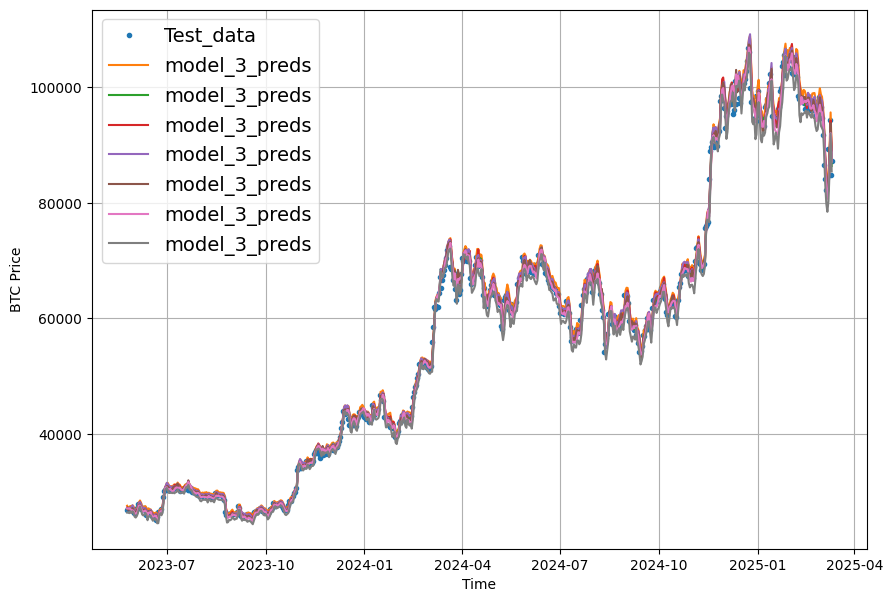

In [58]:
train_windows, test_windows, train_labels, test_labels = prepare_model_data(prices, window_size=30, horizon=HORIZON)
model_preds, model_results = train_model(model_num=3, train_windows=train_windows, test_windows=test_windows, train_labels=train_labels, test_labels=test_labels, horizon=HORIZON)
